In [1]:
import subprocess
subprocess.run(["git", "clone", "https://github.com/sienkozuzanna/generative-models"], check=True)

import sys
sys.path.append("generative-models")
print("Repo cloned successfully")

Cloning into 'generative-models'...


Repo cloned successfully


## Cats vs dogs experiment

In [2]:
import os
import zipfile
import shutil
from pathlib import Path
from PIL import Image
from tqdm import tqdm
import random
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.optim as optim

from src.data.dataset import get_dataloader
from src.models.dcgan import Generator, Discriminator
from src.training.utils import set_seed, save_results, gan_loss
from src.evaluation.metrics import evaluate_model
from src.visualisations.plots import (
    plot_loss_curves_multiseed,
    plot_image_grid,
    print_summary_table,
)
from src.evaluation.metrics import interpolation_metrics
from src.visualisations.plots import plot_interpolation

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: Tesla T4


In [4]:
import kagglehub

path = kagglehub.competition_download("dogs-vs-cats")

print(path)

/kaggle/input/competitions/dogs-vs-cats


In [5]:
from pathlib import Path

root = Path(path)

for p in root.iterdir():
    print(p)

/kaggle/input/competitions/dogs-vs-cats/test1.zip
/kaggle/input/competitions/dogs-vs-cats/train.zip
/kaggle/input/competitions/dogs-vs-cats/sampleSubmission.csv


In [6]:
import zipfile

train_zip = root / "train.zip"
extract_dir = Path("/kaggle/working/dogs_vs_cats_raw")

with zipfile.ZipFile(train_zip, "r") as zip_ref:
    zip_ref.extractall(extract_dir)

print("Done")

Done


In [7]:
for p in extract_dir.iterdir():
    print(p)

/kaggle/working/dogs_vs_cats_raw/train


In [8]:
INPUT_DIR = "/kaggle/working/dogs_vs_cats_raw/train"
OUTPUT_DIR = "/kaggle/working/dogs_vs_cats_64"

In [9]:
def center_crop_square(img):
    w, h = img.size
    s = min(w, h)
    left = (w - s) // 2
    top = (h - s) // 2
    return img.crop((left, top, left + s, top + s))


def preprocess_dogs_vs_cats(
    input_dir,
    output_dir,
    size=64,
    max_per_class=None,
    seed=42
):
    input_dir = Path(input_dir)
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    cat_paths = sorted(input_dir.glob("cat.*.jpg"))
    dog_paths = sorted(input_dir.glob("dog.*.jpg"))

    print(f"Found cats: {len(cat_paths)}")
    print(f"Found dogs: {len(dog_paths)}")

    random.seed(seed)

    if max_per_class is not None:
        cat_paths = random.sample(cat_paths, min(max_per_class, len(cat_paths)))
        dog_paths = random.sample(dog_paths, min(max_per_class, len(dog_paths)))

    all_paths = [(p, "cat") for p in cat_paths] + [(p, "dog") for p in dog_paths]
    random.shuffle(all_paths)

    saved = 0
    skipped = 0

    for img_path, label in tqdm(all_paths, desc=f"Preprocessing {size}x{size}"):
        try:
            img = Image.open(img_path).convert("RGB")
            img = center_crop_square(img)
            img = img.resize((size, size), Image.LANCZOS)

            out_name = f"{label}_{img_path.stem}.jpg"
            img.save(output_dir / out_name)
            saved += 1

        except Exception as e:
            skipped += 1
            print(f"Skipped {img_path.name}: {e}")

    print(f"Saved: {saved}")
    print(f"Skipped: {skipped}")

In [10]:
preprocess_dogs_vs_cats(
    input_dir=INPUT_DIR,
    output_dir=OUTPUT_DIR,
    size=64,
    max_per_class=5000,   # None for all 25k
    seed=42
)

Found cats: 12500
Found dogs: 12500


Preprocessing 64x64: 100%|██████████| 10000/10000 [00:28<00:00, 347.67it/s]

Saved: 10000
Skipped: 0


Processed images: 10000


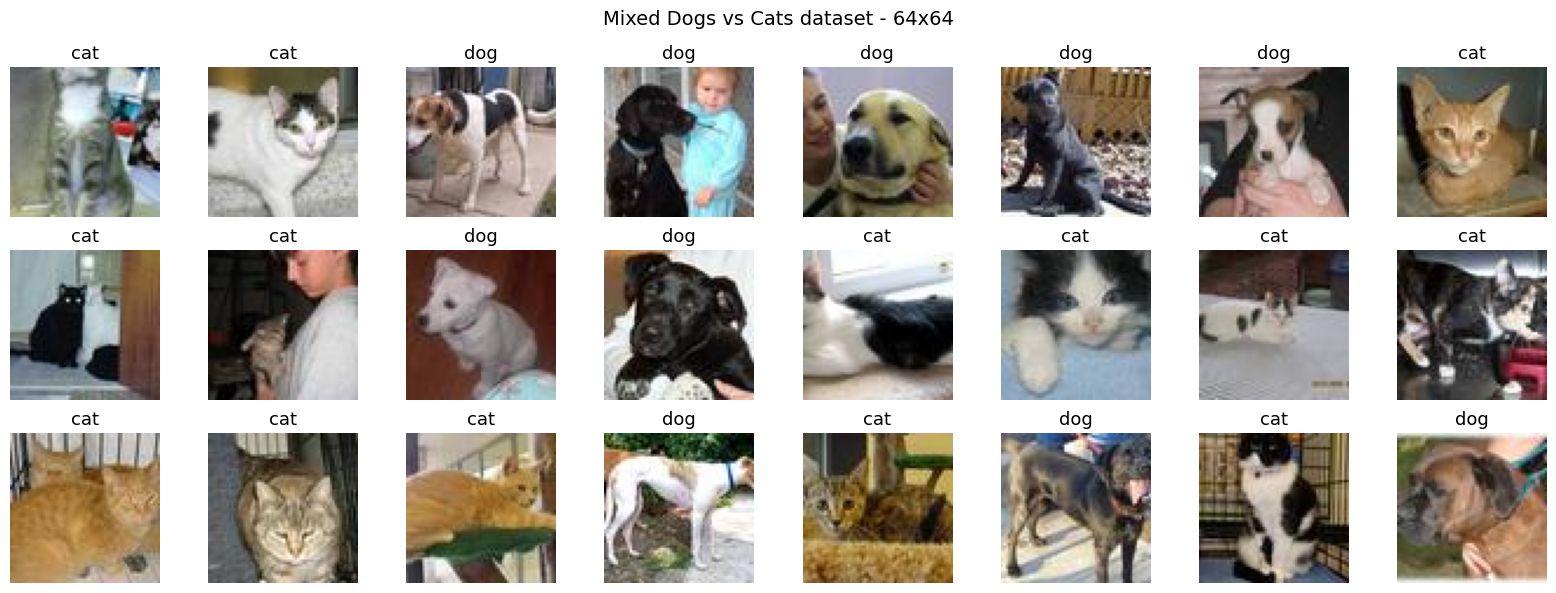

In [11]:
processed = list(Path(OUTPUT_DIR).glob("*.jpg"))
print(f"Processed images: {len(processed)}")

sample = np.random.choice(processed, 24, replace=False)

fig, axes = plt.subplots(3, 8, figsize=(16, 6))
for ax, p in zip(axes.flatten(), sample):
    ax.imshow(Image.open(p))
    ax.set_title(p.name.split("_")[0])
    ax.axis("off")

plt.suptitle("Mixed Dogs vs Cats dataset - 64x64", fontsize=14)
plt.tight_layout()
plt.show()

In [27]:
CONFIG = {
    # data
    "data_dir": "/kaggle/working/dogs_vs_cats_64",
    "image_size": 64,
    "batch_size": 64,

    # model
    "latent_dim": 64,   # the best for dcgan from experiments
    "base_channels": 64,

    # training
    "epochs": 50,
    "lr_g": 5e-4,   # the best for dcgan from experiments
    "lr_d": 5e-4,   # the best for dcgan from experiments
    "beta1": 0.5,
    "n_critic": 1,
    "seeds": [42],    # just one seed

    # saving
    "checkpoint_dir": "/kaggle/working/dcgan_outputs_dogs_vs_cats",
    "sample_interval": 10,

    # evaluation
    "n_eval_samples": 1000,
}

Path(CONFIG["checkpoint_dir"]).mkdir(parents=True, exist_ok=True)
print(CONFIG)

{'data_dir': '/kaggle/working/dogs_vs_cats_64', 'image_size': 64, 'batch_size': 64, 'latent_dim': 64, 'base_channels': 64, 'epochs': 50, 'lr_g': 0.0005, 'lr_d': 0.0005, 'beta1': 0.5, 'n_critic': 1, 'seeds': [42], 'checkpoint_dir': '/kaggle/working/dcgan_outputs_dogs_vs_cats', 'sample_interval': 10, 'n_eval_samples': 1000}


Images: 10000
Batches/epoch: 156


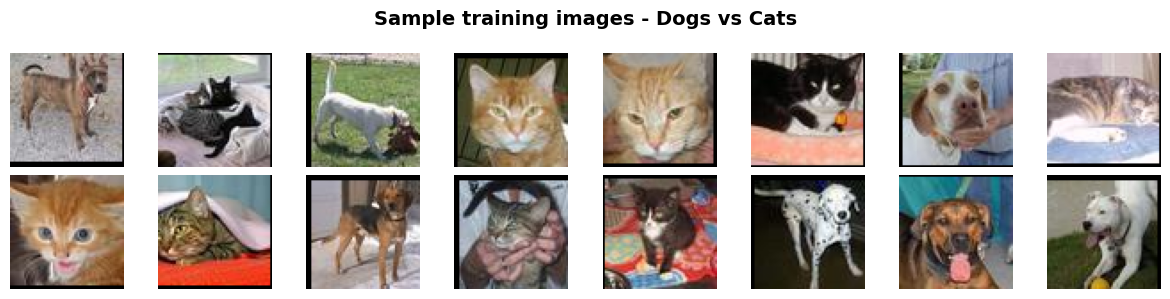

In [28]:
loader = get_dataloader(
    CONFIG["data_dir"],
    image_size=CONFIG["image_size"],
    batch_size=CONFIG["batch_size"],
    augment=True,
)

print(f"Images: {len(loader.dataset)}")
print(f"Batches/epoch: {len(loader)}")

batch = next(iter(loader))
plot_image_grid(batch[:16], title="Sample training images - Dogs vs Cats", nrow=8)

In [29]:
G = Generator(latent_dim=CONFIG["latent_dim"], base_channels=CONFIG["base_channels"], image_size=CONFIG["image_size"]).to(device)
D = Discriminator(base_channels=CONFIG["base_channels"], image_size=CONFIG["image_size"]).to(device)

z_test = torch.randn(4, CONFIG["latent_dim"], device=device)
fake_test = G(z_test)
logit_test = D(fake_test)
print(f"G output: {fake_test.shape}  | D output: {logit_test.shape}")
del G, D, z_test, fake_test, logit_test

G output: torch.Size([4, 3, 64, 64])  | D output: torch.Size([4, 1, 1, 1])


In [30]:
def train_one_seed(config, seed):
    """
    Full DCGAN training run for one seed.
    Returns (generator, result_dict).
    """
    set_seed(seed)
    seed_dir = Path(config["checkpoint_dir"]) / f"seed_{seed}"
    seed_dir.mkdir(parents=True, exist_ok=True)

    G = Generator(latent_dim=config["latent_dim"], base_channels=config["base_channels"], image_size=config["image_size"]).to(device)
    D = Discriminator(base_channels=config["base_channels"], image_size=config["image_size"]).to(device)

    opt_G = optim.Adam(G.parameters(), lr=config["lr_g"], betas=(config["beta1"], 0.999))
    opt_D = optim.Adam(D.parameters(), lr=config["lr_d"], betas=(config["beta1"], 0.999))

    history = {"loss_g": [], "loss_d": []}

    for epoch in range(1, config["epochs"] + 1):
        G.train(); D.train()
        loss_g_sum = loss_d_sum = 0.0

        for real in loader:
            real = real.to(device)
            B = real.size(0)

            #discriminator steps
            for _ in range(config["n_critic"]):
                z = torch.randn(B, config["latent_dim"], device=device)
                with torch.no_grad():
                    fake = G(z)
                opt_D.zero_grad()
                loss_d = (gan_loss(D(real), target_real=True)
                        + gan_loss(D(fake.detach()), target_real=False)) * 0.5
                loss_d.backward()
                opt_D.step()

            #generator step
            z = torch.randn(B, config["latent_dim"], device=device)
            fake = G(z)
            opt_G.zero_grad()
            loss_g = gan_loss(D(fake), target_real=True)
            loss_g.backward()
            opt_G.step()

            loss_g_sum += loss_g.item()
            loss_d_sum += loss_d.item()

        n = len(loader)
        avg_g = loss_g_sum / n
        avg_d = loss_d_sum / n
        history["loss_g"].append(avg_g)
        history["loss_d"].append(avg_d)

        print(f"  [seed={seed}] Epoch [{epoch:3d}/{config['epochs']}] "
              f"loss_G: {avg_g:.4f}  loss_D: {avg_d:.4f}")

        if epoch % config["sample_interval"] == 0:
            G.eval()
            with torch.no_grad():
                samples = G.generate(16, device)
            plot_image_grid(samples,
                title=f"Generated — seed {seed}, epoch {epoch}",
                save_path=str(seed_dir / f"samples_epoch_{epoch:03d}.png"))
            G.train()

    G.eval()
    metrics = evaluate_model(
        generate_fn=lambda n: G.generate(n, device),
        real_loader=loader,
        device=device,
        n_samples=config["n_eval_samples"],
    )
    torch.save(G.state_dict(), seed_dir / "best_G.pt")
    torch.save(D.state_dict(), seed_dir / "best_D.pt")

    result = {
        "seed": seed,
        "history": history,
        "fid": metrics["fid"],
        "is_mean": metrics["is_mean"],
        "is_std": metrics["is_std"],
    }
    save_results(result, str(seed_dir / "result.json"))
    return G, result


Training mixed Dogs vs Cats DCGAN, seed 42
  [seed=42] Epoch [  1/50] loss_G: 6.3036  loss_D: 0.6682
  [seed=42] Epoch [  2/50] loss_G: 6.0560  loss_D: 0.2978
  [seed=42] Epoch [  3/50] loss_G: 5.7265  loss_D: 0.2939
  [seed=42] Epoch [  4/50] loss_G: 6.3367  loss_D: 0.2569
  [seed=42] Epoch [  5/50] loss_G: 4.7307  loss_D: 0.3506
  [seed=42] Epoch [  6/50] loss_G: 5.0768  loss_D: 0.3145
  [seed=42] Epoch [  7/50] loss_G: 4.6140  loss_D: 0.2596
  [seed=42] Epoch [  8/50] loss_G: 3.8907  loss_D: 0.3741
  [seed=42] Epoch [  9/50] loss_G: 3.1561  loss_D: 0.4291
  [seed=42] Epoch [ 10/50] loss_G: 3.3814  loss_D: 0.3962


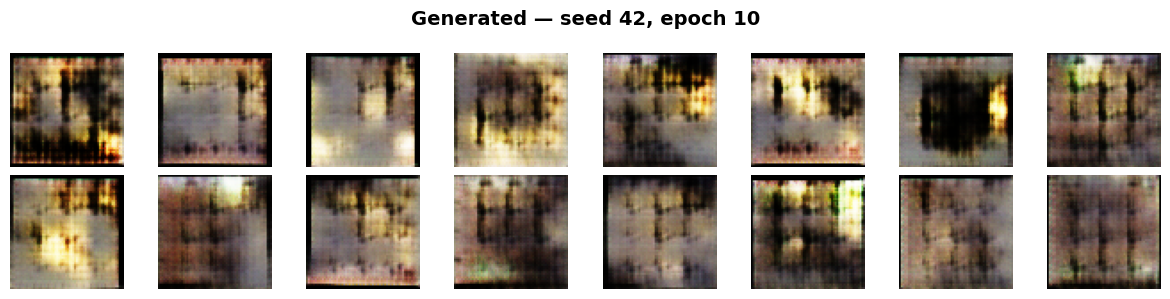

  [seed=42] Epoch [ 11/50] loss_G: 2.9977  loss_D: 0.4680
  [seed=42] Epoch [ 12/50] loss_G: 3.1708  loss_D: 0.4276
  [seed=42] Epoch [ 13/50] loss_G: 3.3074  loss_D: 0.4122
  [seed=42] Epoch [ 14/50] loss_G: 3.2767  loss_D: 0.4094
  [seed=42] Epoch [ 15/50] loss_G: 3.3818  loss_D: 0.3844
  [seed=42] Epoch [ 16/50] loss_G: 3.2640  loss_D: 0.4016
  [seed=42] Epoch [ 17/50] loss_G: 3.2016  loss_D: 0.4203
  [seed=42] Epoch [ 18/50] loss_G: 3.2113  loss_D: 0.4052
  [seed=42] Epoch [ 19/50] loss_G: 2.8307  loss_D: 0.4477
  [seed=42] Epoch [ 20/50] loss_G: 2.6585  loss_D: 0.4461


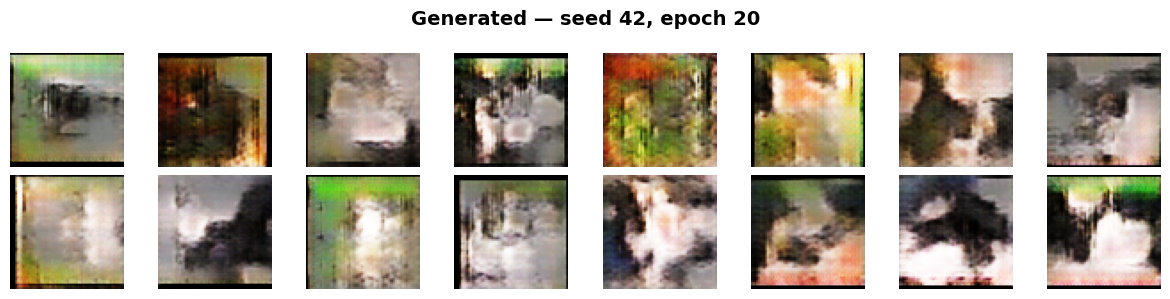

  [seed=42] Epoch [ 21/50] loss_G: 2.6203  loss_D: 0.4674
  [seed=42] Epoch [ 22/50] loss_G: 2.5663  loss_D: 0.4556
  [seed=42] Epoch [ 23/50] loss_G: 2.4741  loss_D: 0.4649
  [seed=42] Epoch [ 24/50] loss_G: 2.5125  loss_D: 0.4321
  [seed=42] Epoch [ 25/50] loss_G: 2.4642  loss_D: 0.4600
  [seed=42] Epoch [ 26/50] loss_G: 2.4001  loss_D: 0.4474
  [seed=42] Epoch [ 27/50] loss_G: 2.4693  loss_D: 0.4392
  [seed=42] Epoch [ 28/50] loss_G: 2.4562  loss_D: 0.4542
  [seed=42] Epoch [ 29/50] loss_G: 2.3798  loss_D: 0.4479
  [seed=42] Epoch [ 30/50] loss_G: 2.4056  loss_D: 0.4435


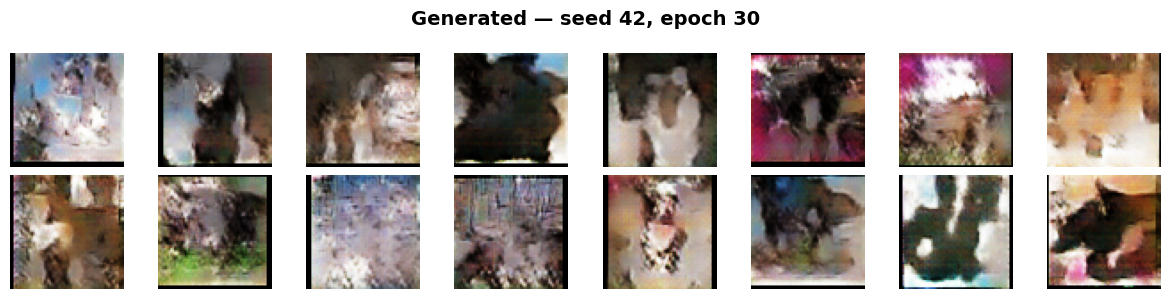

  [seed=42] Epoch [ 31/50] loss_G: 2.4386  loss_D: 0.4479
  [seed=42] Epoch [ 32/50] loss_G: 2.3444  loss_D: 0.4401
  [seed=42] Epoch [ 33/50] loss_G: 2.4235  loss_D: 0.4275
  [seed=42] Epoch [ 34/50] loss_G: 2.5249  loss_D: 0.3995
  [seed=42] Epoch [ 35/50] loss_G: 2.4754  loss_D: 0.4317
  [seed=42] Epoch [ 36/50] loss_G: 2.4813  loss_D: 0.3997
  [seed=42] Epoch [ 37/50] loss_G: 2.5281  loss_D: 0.4165
  [seed=42] Epoch [ 38/50] loss_G: 2.4201  loss_D: 0.4094
  [seed=42] Epoch [ 39/50] loss_G: 2.2931  loss_D: 0.4182
  [seed=42] Epoch [ 40/50] loss_G: 2.3656  loss_D: 0.4467


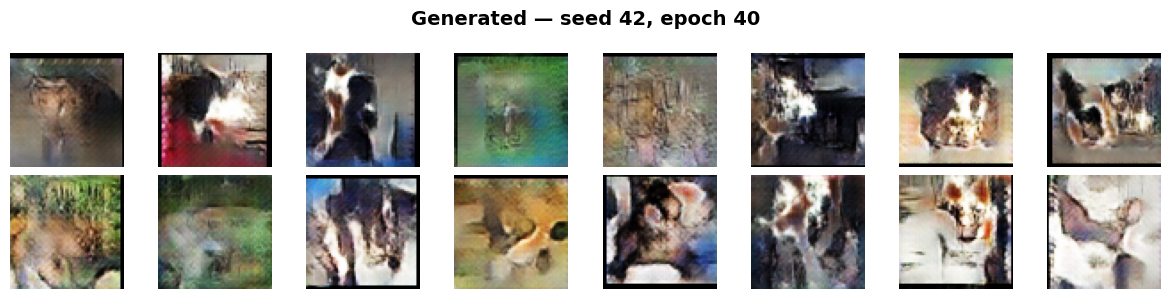

  [seed=42] Epoch [ 41/50] loss_G: 2.4239  loss_D: 0.4046
  [seed=42] Epoch [ 42/50] loss_G: 2.3982  loss_D: 0.4185
  [seed=42] Epoch [ 43/50] loss_G: 2.4875  loss_D: 0.4082
  [seed=42] Epoch [ 44/50] loss_G: 2.4140  loss_D: 0.4166
  [seed=42] Epoch [ 45/50] loss_G: 2.3351  loss_D: 0.4445
  [seed=42] Epoch [ 46/50] loss_G: 2.4345  loss_D: 0.4286
  [seed=42] Epoch [ 47/50] loss_G: 2.2408  loss_D: 0.4171
  [seed=42] Epoch [ 48/50] loss_G: 2.3917  loss_D: 0.4291
  [seed=42] Epoch [ 49/50] loss_G: 2.4044  loss_D: 0.4059
  [seed=42] Epoch [ 50/50] loss_G: 2.4052  loss_D: 0.4038


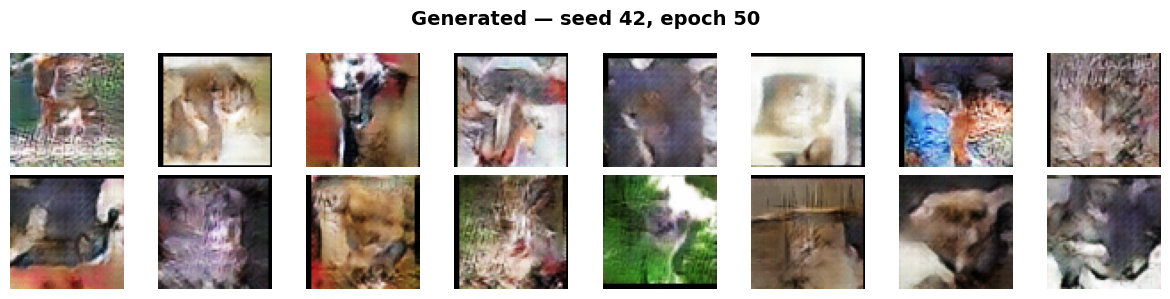

Evaluating with 1000 samples...


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 200MB/s]  


  Extracting real image features...


  Real:  10%|▉         | 15/156 [00:00<00:05, 27.75it/s]


  Generating fake images...
  Computing FID...
  Computing Inception Score...

EVALUATION RESULTS
FID: 141.59  (lower is better)
Inception Score: 3.39 +/- 0.23  (higher is better)
Mixed Dogs vs Cats experiment done.


In [31]:
mixed_results = {}
mixed_models = {}


for seed in CONFIG["seeds"]:
    print(f"\n{'='*55}")
    print(f"Training mixed Dogs vs Cats DCGAN, seed {seed}")
    print(f"{'='*55}")

    G, result = train_one_seed(CONFIG, seed)
    mixed_results[seed] = result
    mixed_models[seed] = G

print("Mixed Dogs vs Cats experiment done.")

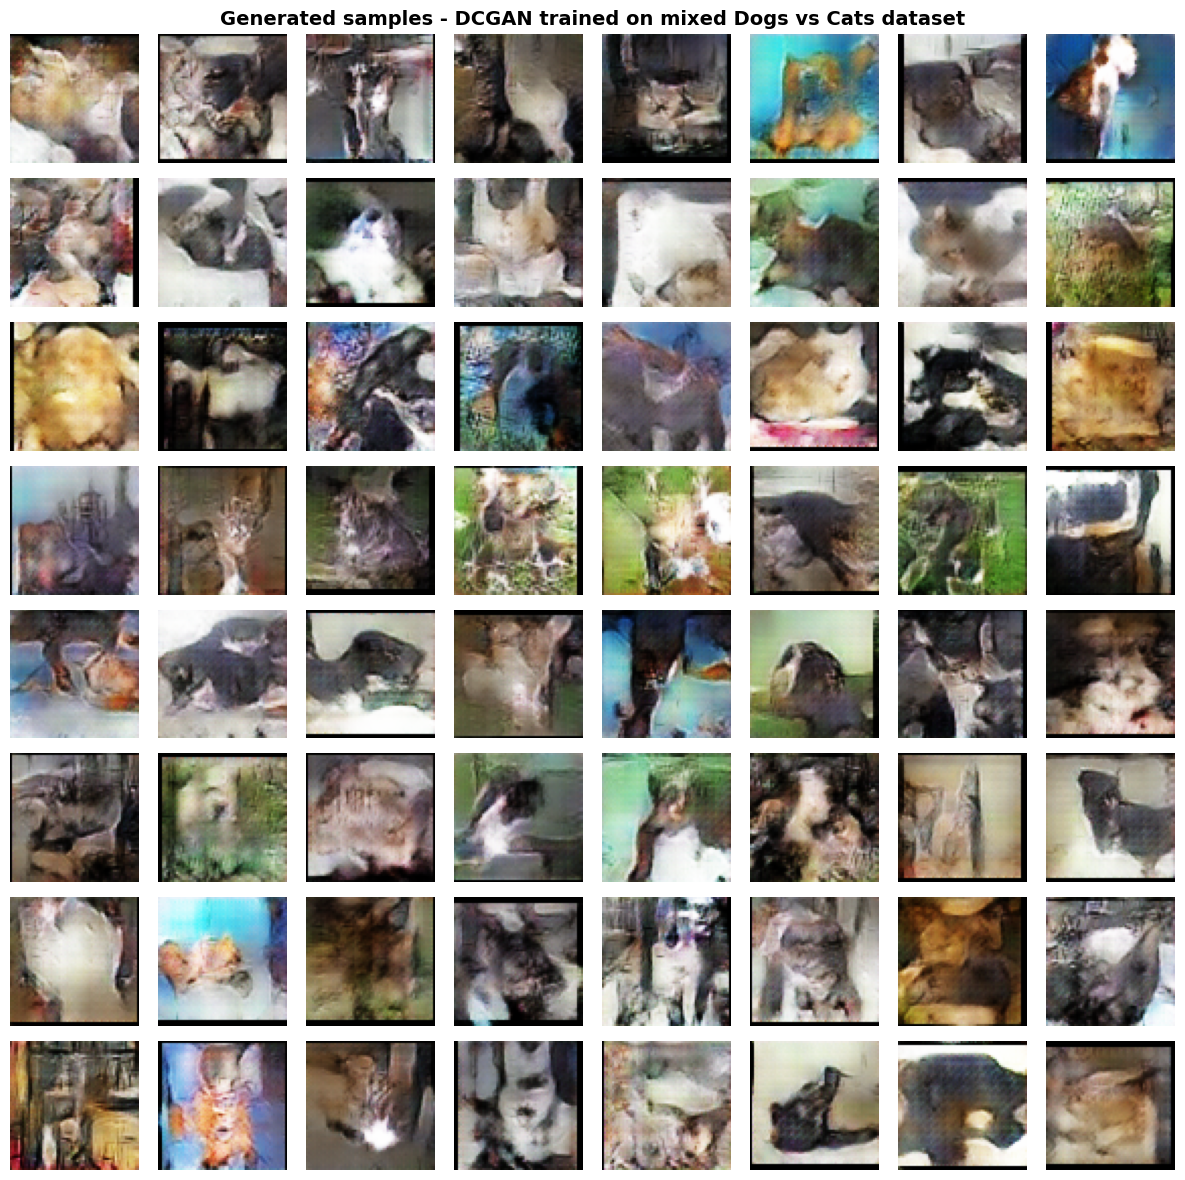

In [36]:
G = mixed_models[42]
G.eval()

with torch.no_grad():
    samples = G.generate(64, device)

plot_image_grid(
    samples,
    title="Generated samples - DCGAN trained on mixed Dogs vs Cats dataset",
    nrow=8,
    save_path="/kaggle/working/dogs_vs_cats_generated_grid.png"
)